# Step 4 — TF-IDF Divergence
**Project:** Same Reality, Different Words  
**Author:** Paula Andrea Jaramillo  
**Program:** MSc Data Science for Society and Business — Constructor University Bremen

## Objective
Compute TF-IDF representations of the domain-filtered corpus and identify the terms that best **discriminate between registers**.

**Two analytical layers:**
1. **Per-register TF-IDF profiles** — which terms are most characteristic of each register (highest mean TF-IDF weight)
2. **Divergence analysis** — which terms show the greatest *difference* in TF-IDF weight across registers, operationalizing the core concept of semantic divergence from the project title

**Connection to research hypotheses:**
- H1 is tested in Step 6 (classifier accuracy)
- **H2 is partially tested here**: domain terms show measurable TF-IDF divergence across registers
- H3 is tested in Step 6 (misclassified documents)

**Input:** `corpus_domain.csv` (output of Step 3) — column used: `text_domain`  
**Output:** `tfidf_matrix.npz` (sparse matrix), `tfidf_feature_names.json`, `corpus_tfidf_meta.csv` (labels + register for matrix rows)

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import json
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Load Corpus

In [21]:
# Adjust path as needed
df = pd.read_csv("corpus_domain.csv")

print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
print(f"Registers: {df['register'].value_counts().to_dict()}")

# Normalize text_domain so TF-IDF sees only valid strings
df["text_domain"] = df["text_domain"].fillna("").astype(str).str.strip()
null_count = df["text_domain"].isnull().sum()
empty_count = df["text_domain"].eq("").sum()
print(f"\nNull text_domain after normalization: {null_count}")
print(f"Empty text_domain after normalization: {empty_count}")

if empty_count > 0:
    print("⚠️  WARNING: Some documents have no domain terms after Step 3.")
    print("They will remain empty strings and produce zero TF-IDF rows instead of artificial placeholder tokens.")

df[["register", "label", "text_domain", "domain_token_count"]].head(4)

Rows: 180 | Columns: 29
Registers: {'institutional': 60, 'popular_media': 60, 'critical_media': 60}

Null text_domain after normalization: 0
Empty text_domain after normalization: 0


,register,label,text_domain,domain_token_count
0,institutional,0,worker formal contract registration urban rura...,8
1,institutional,0,protection coverage worker informal statutory ...,8
2,institutional,0,labor formality metropolitan employer complian...,9
3,institutional,0,informal employment worker structural formality,5


## 3. TF-IDF Vectorization

**Key decisions:**
- `analyzer='word'` — token-level (already lemmatized in Step 1)
- `ngram_range=(1, 2)` — unigrams and bigrams to capture multi-word expressions (e.g., *social protection*, *informal sector*)
- `min_df=2` — ignore terms appearing in fewer than 2 documents (avoids noise from hapax legomena)
- `max_df=0.95` — ignore terms appearing in more than 95% of documents (near-universal terms carry no discriminative power)
- `sublinear_tf=True` — applies log(1 + tf) to compress high-frequency terms; standard practice in text classification
- No additional `stop_words` — already removed in Step 1

In [22]:
vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

tfidf_matrix = vectorizer.fit_transform(df["text_domain"])
feature_names = vectorizer.get_feature_names_out()
zero_vector_docs = int((tfidf_matrix.getnnz(axis=1) == 0).sum())

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"  Rows (documents): {tfidf_matrix.shape[0]}")
print(f"  Columns (features): {tfidf_matrix.shape[1]}")
print(f"  Zero-vector documents: {zero_vector_docs}")
print(f"  Sparsity: {1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.3f}")
print(f"\nSample features: {list(feature_names[:20])}")

TF-IDF matrix shape: (180, 171)
  Rows (documents): 180
  Columns (features): 171
  Zero-vector documents: 0
  Sparsity: 0.964

Sample features: ['affiliation', 'benefit', 'cash', 'cash contract', 'cash wage', 'compliance', 'contract', 'contract earn', 'contract pay', 'contractor', 'contribution', 'contribution cost', 'contribution obligation', 'cooperative', 'cost', 'cost formal', 'coverage', 'coverage informal', 'coverage worker', 'daily']


## 4. Per-Register TF-IDF Profiles

For each register, compute the **mean TF-IDF weight** across all documents in that class.  
The top-N terms by mean weight are the most *characteristic* terms of that register.

In [23]:
register_order = ["institutional", "popular_media", "critical_media"]
register_labels = ["Institutional", "Popular Media", "Critical Media"]

# Convert to dense array for per-register calculations
tfidf_dense = tfidf_matrix.toarray()

# Mean TF-IDF per register
register_profiles = {}
for reg in register_order:
    mask = df["register"] == reg
    register_profiles[reg] = tfidf_dense[mask].mean(axis=0)

profiles_df = pd.DataFrame(register_profiles, index=feature_names)

# Top 20 terms per register
TOP_N = 20
print(f"=== Top {TOP_N} characteristic terms per register ===")
for reg, label in zip(register_order, register_labels):
    top = profiles_df[reg].nlargest(TOP_N)
    print(f"\n{label}:")
    print([f"{t}({v:.4f})" for t, v in top.items()])

=== Top 20 characteristic terms per register ===

Institutional:
['employment(0.1367)', 'worker(0.1202)', 'informal(0.1080)', 'formal(0.0870)', 'informal employment(0.0842)', 'labor(0.0725)', 'formality(0.0705)', 'formal employment(0.0656)', 'informal worker(0.0635)', 'informality(0.0571)', 'contribution(0.0421)', 'labor market(0.0415)', 'compliance(0.0397)', 'registration(0.0394)', 'affiliation(0.0362)', 'market(0.0361)', 'reveal(0.0355)', 'worker formal(0.0329)', 'employer(0.0318)', 'protection(0.0285)']

Popular Media:
['sell(0.1220)', 'pay(0.0962)', 'work(0.0913)', 'earn(0.0834)', 'street(0.0783)', 'informal(0.0730)', 'income(0.0634)', 'pension(0.0588)', 'contract(0.0520)', 'woman(0.0503)', 'saving(0.0501)', 'informal work(0.0488)', 'woman sell(0.0429)', 'formal(0.0390)', 'job(0.0388)', 'food(0.0384)', 'tip(0.0378)', 'cash(0.0346)', 'health(0.0342)', 'cost(0.0339)']

Critical Media:
['labor(0.1387)', 'worker(0.1049)', 'informal(0.0808)', 'contribution(0.0770)', 'employment(0.0641)'

## 5. Divergence Analysis

**TF-IDF divergence** is defined here as the **range** of mean TF-IDF weights across registers for each term:

$$\text{divergence}(t) = \max_{r} \bar{w}_{t,r} - \min_{r} \bar{w}_{t,r}$$

Terms with high divergence appear with very different weights across registers — they are the lexical markers of semantic divergence, directly operationalizing **H2**.

We also compute **which register dominates** each high-divergence term (the register with the highest mean weight).

In [24]:
profiles_df["divergence"] = profiles_df[register_order].max(axis=1) - profiles_df[register_order].min(axis=1)
profiles_df["dominant_register"] = profiles_df[register_order].idxmax(axis=1)

# Top divergent terms overall
top_divergent = profiles_df.nlargest(30, "divergence")

print("=== Top 30 most divergent terms ===")
print(top_divergent[["institutional", "popular_media", "critical_media", "divergence", "dominant_register"]]
      .round(4).to_string())

=== Top 30 most divergent terms ===
                     institutional  popular_media  critical_media  divergence dominant_register
labor                       0.0725         0.0064          0.1387      0.1323    critical_media
sell                        0.0000         0.1220          0.0000      0.1220     popular_media
employment                  0.1367         0.0269          0.0641      0.1098     institutional
worker                      0.1202         0.0220          0.1049      0.0982     institutional
pay                         0.0000         0.0962          0.0000      0.0962     popular_media
informal employment         0.0842         0.0000          0.0275      0.0842     institutional
earn                        0.0000         0.0834          0.0109      0.0834     popular_media
street                      0.0151         0.0783          0.0000      0.0783     popular_media
contribution                0.0421         0.0000          0.0770      0.0770    critical_media
form

## 6. Visualizations

### 6.1 Top 15 Terms per Register — Horizontal Bar Charts

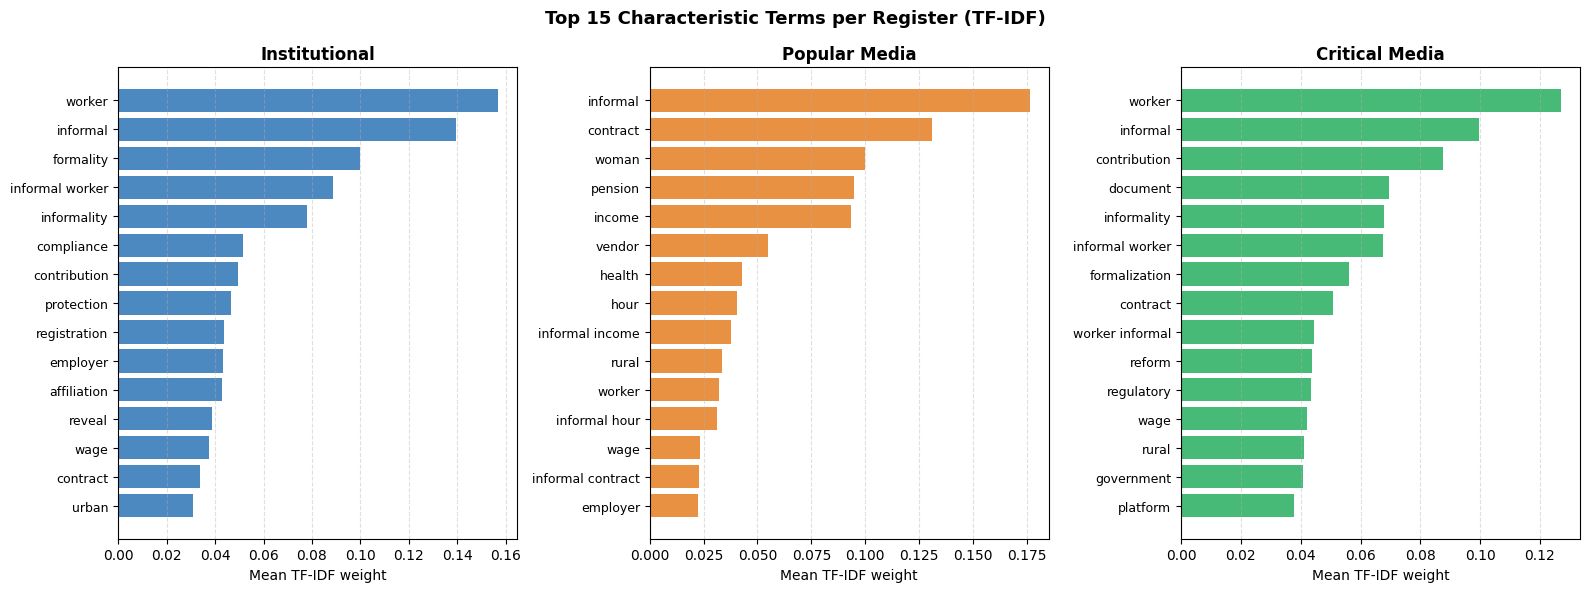

Figure saved: step4_top_terms_tfidf.png


In [8]:
colors = ["#2E75B6", "#E67E22", "#27AE60"]
TOP_PLOT = 15

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, reg, label, color in zip(axes, register_order, register_labels, colors):
    top = profiles_df[reg].nlargest(TOP_PLOT).sort_values(ascending=True)
    ax.barh(top.index, top.values, color=color, alpha=0.85)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Mean TF-IDF weight", fontsize=10)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Top 15 Characteristic Terms per Register (TF-IDF)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("step4_top_terms_tfidf.png", dpi=150)
plt.show()
print("Figure saved: step4_top_terms_tfidf.png")

### 6.2 Top 20 Divergent Terms — Grouped Bar Chart

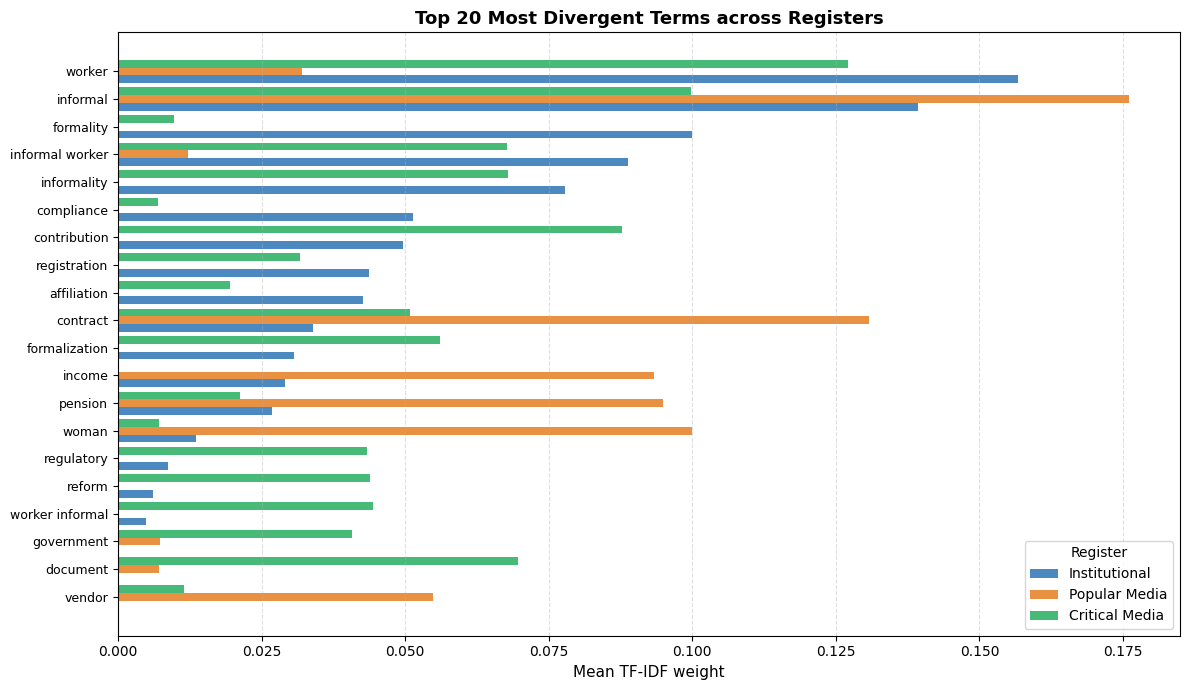

Figure saved: step4_divergent_terms.png


In [9]:
TOP_DIV_PLOT = 20
div_plot = profiles_df.nlargest(TOP_DIV_PLOT, "divergence")[register_order].sort_values(
    "institutional", ascending=True
)

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(div_plot))
width = 0.28

for i, (reg, label, color) in enumerate(zip(register_order, register_labels, colors)):
    ax.barh(x + i * width, div_plot[reg], width, label=label, color=color, alpha=0.85)

ax.set_yticks(x + width)
ax.set_yticklabels(div_plot.index, fontsize=9)
ax.set_xlabel("Mean TF-IDF weight", fontsize=11)
ax.set_title("Top 20 Most Divergent Terms across Registers",
             fontsize=13, fontweight="bold")
ax.legend(title="Register", fontsize=10)
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("step4_divergent_terms.png", dpi=150)
plt.show()
print("Figure saved: step4_divergent_terms.png")

### 6.3 TF-IDF Heatmap — Top 25 Divergent Terms

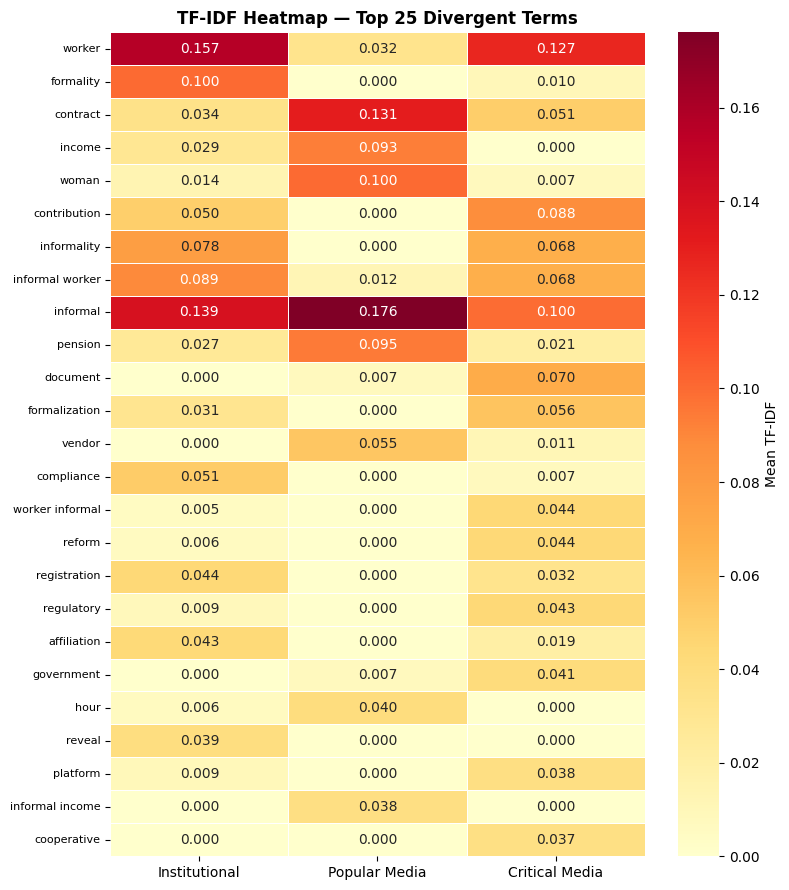

Figure saved: step4_tfidf_heatmap.png


In [10]:
TOP_HEAT = 25
heat_data = profiles_df.nlargest(TOP_HEAT, "divergence")[register_order]
heat_data.columns = register_labels

fig, ax = plt.subplots(figsize=(8, 9))
sns.heatmap(
    heat_data, annot=True, fmt=".3f", cmap="YlOrRd",
    linewidths=0.5, ax=ax, cbar_kws={"label": "Mean TF-IDF"}
)
ax.set_title("TF-IDF Heatmap — Top 25 Divergent Terms",
             fontsize=12, fontweight="bold")
ax.set_xticklabels(register_labels, rotation=0, fontsize=10)
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.savefig("step4_tfidf_heatmap.png", dpi=150)
plt.show()
print("Figure saved: step4_tfidf_heatmap.png")

### 6.4 Divergence Score Distribution by Dominant Register

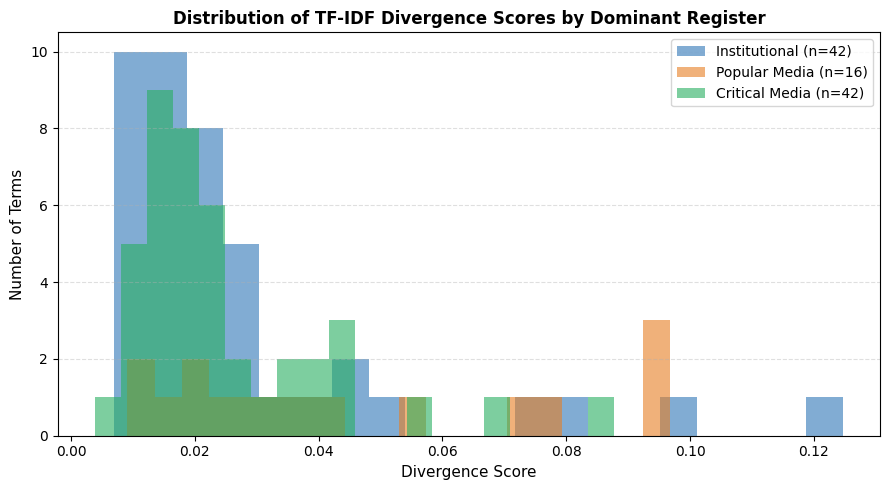

Figure saved: step4_divergence_distribution.png


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

for reg, label, color in zip(register_order, register_labels, colors):
    subset = profiles_df[profiles_df["dominant_register"] == reg]["divergence"]
    ax.hist(subset, bins=20, alpha=0.6, color=color, label=f"{label} (n={len(subset)})")

ax.set_xlabel("Divergence Score", fontsize=11)
ax.set_ylabel("Number of Terms", fontsize=11)
ax.set_title("Distribution of TF-IDF Divergence Scores by Dominant Register",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("step4_divergence_distribution.png", dpi=150)
plt.show()
print("Figure saved: step4_divergence_distribution.png")

## 7. H2 Evidence Summary

Direct evidence for Hypothesis 2: *domain terms show divergence in TF-IDF weights across registers.*

In [12]:
print("=== H2 EVIDENCE SUMMARY ===")
print(f"Total features in TF-IDF vocabulary: {len(feature_names)}")
print(f"Mean divergence score across all terms: {profiles_df['divergence'].mean():.4f}")
print(f"Max divergence score: {profiles_df['divergence'].max():.4f}")
print(f"  → Term: {profiles_df['divergence'].idxmax()}")
print(f"  → Dominant register: {profiles_df.loc[profiles_df['divergence'].idxmax(), 'dominant_register']}")

print(f"\nTerms with divergence > 0.05: {(profiles_df['divergence'] > 0.05).sum()}")
print(f"Terms with divergence > 0.10: {(profiles_df['divergence'] > 0.10).sum()}")

print("\nDominant register distribution among all features:")
print(profiles_df["dominant_register"].value_counts().to_string())

print("\n--- Top 5 most divergent terms per register ---")
for reg, label in zip(register_order, register_labels):
    top5 = profiles_df[profiles_df["dominant_register"] == reg].nlargest(5, "divergence")
    print(f"\n{label}: {list(top5.index)}")

=== H2 EVIDENCE SUMMARY ===
Total features in TF-IDF vocabulary: 100
Mean divergence score across all terms: 0.0292
Max divergence score: 0.1247
  → Term: worker
  → Dominant register: institutional

Terms with divergence > 0.05: 14
Terms with divergence > 0.10: 1

Dominant register distribution among all features:
dominant_register
institutional     42
critical_media    42
popular_media     16

--- Top 5 most divergent terms per register ---

Institutional: ['worker', 'formality', 'informality', 'informal worker', 'compliance']

Popular Media: ['contract', 'income', 'woman', 'informal', 'pension']

Critical Media: ['contribution', 'document', 'formalization', 'worker informal', 'reform']


## 8. Save Outputs

In [25]:
# Save sparse TF-IDF matrix
sp.save_npz("tfidf_matrix.npz", tfidf_matrix)
print("Saved: tfidf_matrix.npz")

# Save feature names
with open("tfidf_feature_names.json", "w", encoding="utf-8") as f:
    json.dump(list(feature_names), f, indent=2)
print("Saved: tfidf_feature_names.json")

# Save metadata (labels + register) aligned with matrix rows
meta = df[["prompt_id", "register", "label"]].reset_index(drop=True)
meta.to_csv("corpus_tfidf_meta.csv", index=False)
print("Saved: corpus_tfidf_meta.csv")

# Save profiles for use in Step 5
profiles_df.to_csv("tfidf_profiles_by_register.csv")
print("Saved: tfidf_profiles_by_register.csv")

print(f"\nFiles ready for Step 5:")
print("  tfidf_matrix.npz          — full TF-IDF matrix (180 x N features)")
print("  tfidf_feature_names.json  — vocabulary list")
print("  corpus_tfidf_meta.csv     — row labels (register + label)")
print("  corpus_domain.csv         — full corpus with all columns")

Saved: tfidf_matrix.npz
Saved: tfidf_feature_names.json
Saved: corpus_tfidf_meta.csv
Saved: tfidf_profiles_by_register.csv

Files ready for Step 5:
  tfidf_matrix.npz          — full TF-IDF matrix (180 x N features)
  tfidf_feature_names.json  — vocabulary list
  corpus_tfidf_meta.csv     — row labels (register + label)
  corpus_domain.csv         — full corpus with all columns


## 9. Summary

In [26]:
print("=== STEP 4 SUMMARY ===")
print(f"Vectorizer: TF-IDF | ngram_range=(1,2) | min_df=2 | max_df=0.95 | sublinear_tf=True")
print(f"Matrix shape: {tfidf_matrix.shape}")
print(f"Sparsity: {1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.3f}")
print(f"\nMost divergent term: {profiles_df['divergence'].idxmax()} "
      f"(score={profiles_df['divergence'].max():.4f})")
print(f"H2 supported: terms show measurable TF-IDF divergence across registers")
print("\nNext step: Step 5 — Cosine Similarity")
print("Input files for Step 5: tfidf_matrix.npz, corpus_tfidf_meta.csv")

=== STEP 4 SUMMARY ===
Vectorizer: TF-IDF | ngram_range=(1,2) | min_df=2 | max_df=0.95 | sublinear_tf=True
Matrix shape: (180, 171)
Sparsity: 0.964

Most divergent term: labor (score=0.1323)
H2 supported: terms show measurable TF-IDF divergence across registers

Next step: Step 5 — Cosine Similarity
Input files for Step 5: tfidf_matrix.npz, corpus_tfidf_meta.csv
